# TCGA 

In [1]:
from __future__ import annotations
from pathlib import Path
import pandas as pd
import pyarrow.parquet as pq
import numpy as np

import importlib
import functions
import auxillary_plots
import constants
importlib.reload(constants)
importlib.reload(auxillary_plots)
importlib.reload(functions)
from constants import *


pd.set_option(
    "display.float_format",
    lambda x: f"{x:.2e}" if abs(x) < 0.01 else f"{x:.3f}"
)

PATH_META = PATH_TCGA_META
PATH_COUNTS = PATH_TCGA_COUNTS

print(f'Specificity metric: {SPECIFICITY_METRIC}')
print(f'Specificity threshold: {SPECIFICITY_THR}')
print(f'Figure mode: {FIG_MODE}')

META_COLS = ["Tissue_Organ", "Sample Type", "Project ID", "Cancer_group"]
META_COLS = [c for c in META_COLS if c != TCGA_AGGREGATE_GROUP]

print("PROJ_ROOT =", PROJ_ROOT) 

Specificity metric: Tau
Specificity threshold: 0.8
Figure mode: pdf
PROJ_ROOT = /Users/neuropromotion/Desktop/miRNA/bulk_review


In [2]:
tcga_loader = functions.Load_TCGA_Data(PATH_COUNTS, PATH_META)

In [3]:
linear_df, specificity_tcga_df = tcga_loader.run_pipeline()

Running Tau score, per Tissue_Organ, log2(CPM+1) [log_of_mean]...


In [4]:
cpm = tcga_loader.CPM(log=True)

specificity_tcga_df["tcga_tissues"] = specificity_tcga_df.apply(
    lambda row: functions.get_top_tissues_expression(row, cpm, threshold=0), 
    axis=1
)

In [5]:
specificity_tcga_df

,mature_name,Tau_tcga,tcga_tissues
0,hsa-mir-302d-3p,0.986,"Testis [0.74], Stomach [0.09], Liver–Gallbladd..."
1,hsa-mir-302a-3p,0.984,"Testis [0.72], Stomach [0.13], Liver–Gallbladd..."
2,hsa-mir-302a-5p,0.973,"Testis [0.60], Stomach [0.08], Liver–Gallbladd..."
3,hsa-mir-302b-3p,0.969,"Testis [0.57], Stomach [0.12], Liver–Gallbladd..."
4,hsa-mir-122-3p,0.966,"Liver–Gallbladder [0.55], Kidney [0.15], Testi..."
...,...,...,...
389,hsa-mir-532-5p,0.104,"Skin [0.04], Thorax [0.04], Soft Tissues [0.04]"
390,hsa-mir-151a-3p,0.102,"Fallopian tube [0.04], Skin [0.04], Bladder [0..."
391,hsa-mir-30d-5p,0.089,"Skin [0.04], Lung [0.04], Kidney [0.04]"
392,hsa-mir-361-5p,0.088,"Bone Marrow [0.04], Skin [0.04], Thorax [0.04]"


In [6]:
specificity_tcga_df.to_csv(TAB_OUT / f'{SPECIFICITY_METRIC}_tcga.csv')

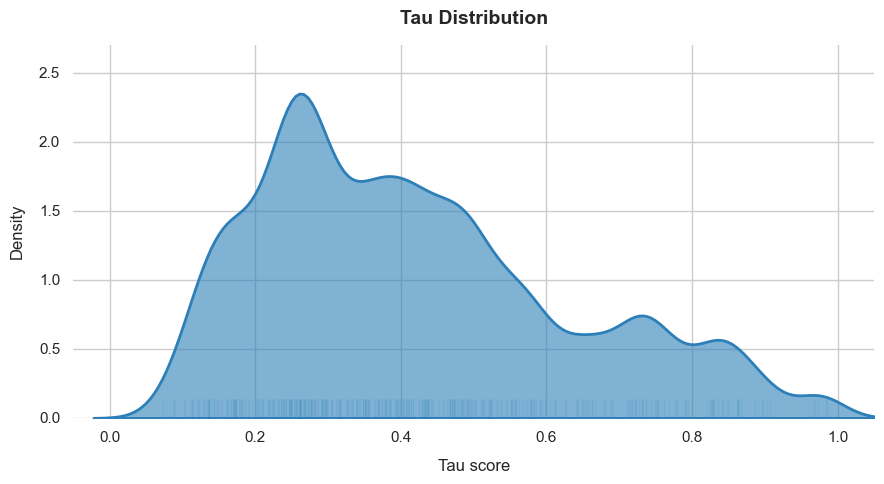

In [7]:
auxillary_plots.plot_specificity_distribution(specificity_tcga_df, 
                            f'{SPECIFICITY_METRIC}_tcga', 
                            save_path=FIG_OUT / f'{SPECIFICITY_METRIC}_distributions_TCGA.{FIG_MODE}')

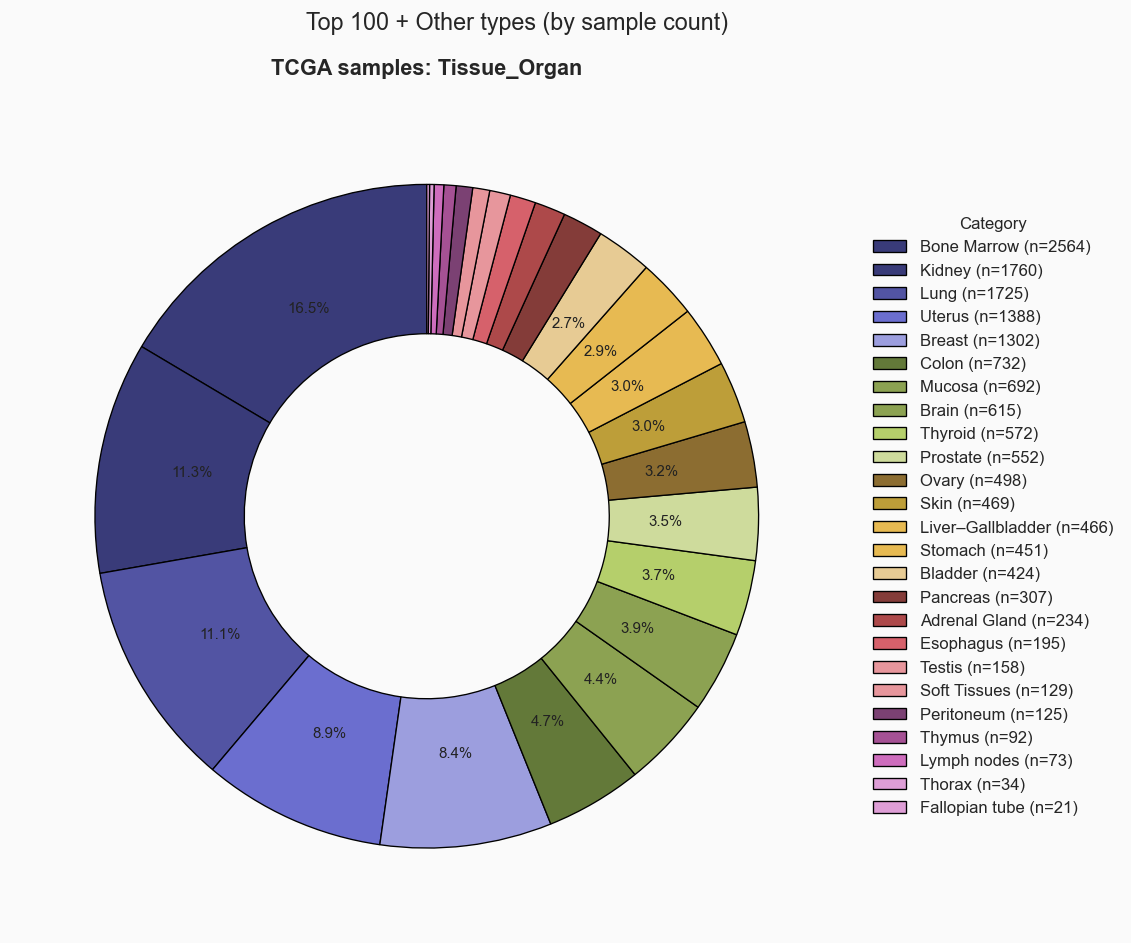

In [8]:
tcga_loader.plot_pie(save_path=FIG_OUT / f'tcga_pie_type.{FIG_MODE}')

In [9]:
de_all, proj_tab, eligible_projects = tcga_loader.tumor_vs_normal()

In [10]:
de_all.head()

,mature_name,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,project_id,n_normal,n_tumor
0,hsa-let-7a-3p,64.757,0.638,0.333,1.915,0.055,0.078,CGCI-BLGSP,10,236
1,hsa-let-7b-3p,15.362,1.361,0.360,3.781,1.56e-04,3.37e-04,CGCI-BLGSP,10,236
2,hsa-let-7b-5p,13944.330,1.891,0.337,5.619,1.92e-08,6.49e-08,CGCI-BLGSP,10,236
3,hsa-let-7d-3p,1291.701,-0.586,0.375,-1.561,0.119,0.152,CGCI-BLGSP,10,236
4,hsa-let-7d-5p,823.763,-0.631,0.213,-2.959,3.09e-03,5.32e-03,CGCI-BLGSP,10,236


In [11]:
proj_tab[proj_tab.index.isin(eligible_projects)].to_csv(TAB_OUT / 'eligible_projects.csv')
de_all.to_csv(TAB_OUT / 'de_all.csv', index=False)

# xlsx
de_all['baseMean'] = de_all['baseMean'].round(3)
de_all['log2FoldChange'] = de_all['log2FoldChange'].round(3)
de_all['lfcSE'] = de_all['lfcSE'].round(3)
de_all['stat'] = de_all['stat'].round(3)
de_all['pvalue'] = de_all['pvalue'].map(lambda x: f"{x:.2e}")
de_all['padj'] = de_all['padj'].map(lambda x: f"{x:.2e}")
de_all.to_excel(TAB_OUT / 'de_all.xlsx', index=False)

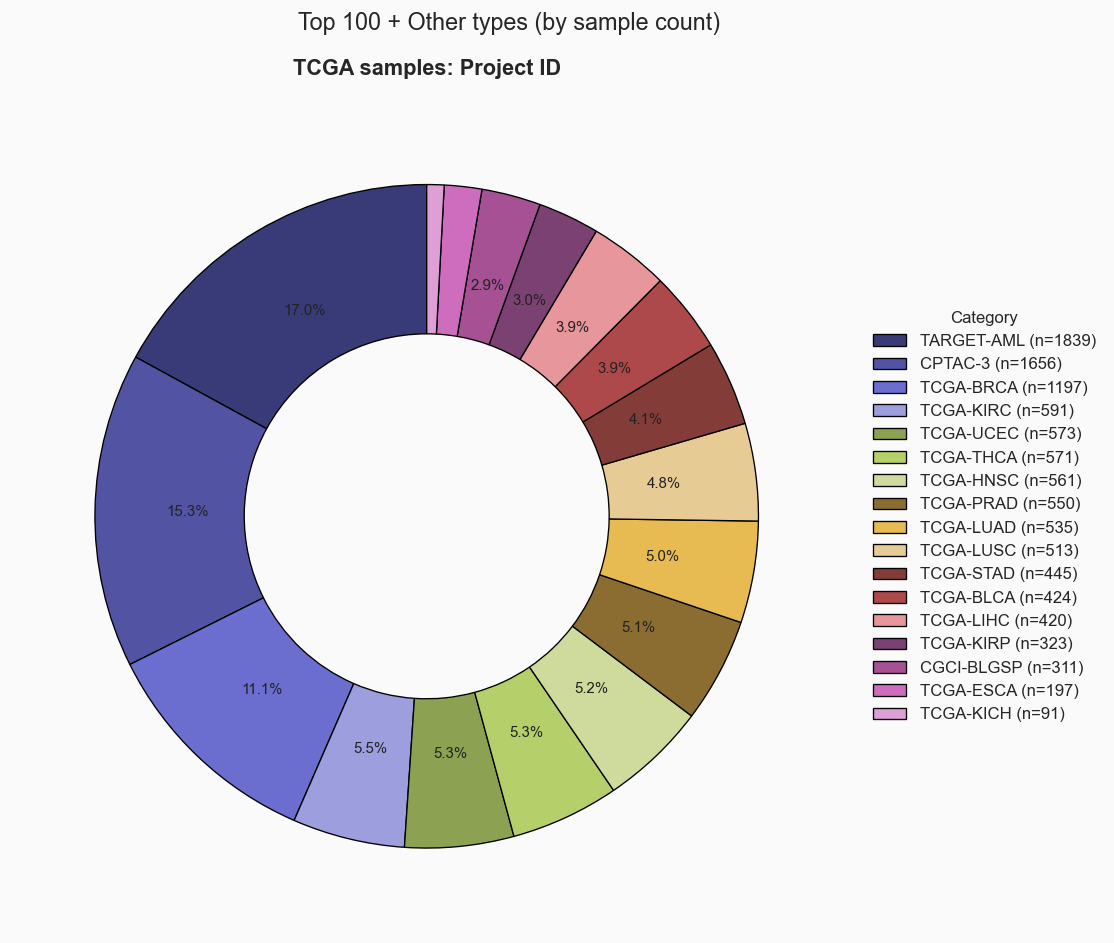

In [12]:
tcga_loader.plot_pie('Project ID', eligible_cols=eligible_projects, save_path=FIG_OUT / f'tcga_pie_project.{FIG_MODE}')

## Binomial test

In [13]:
rows: list[dict] = []
for mir in de_all['mature_name'].unique():
    sub = de_all.loc[de_all["mature_name"] == mir, ["project_id", "log2FoldChange", "padj"]].copy()
    sub["padj"] = pd.to_numeric(sub["padj"], errors="coerce")
    sub["log2FoldChange"] = pd.to_numeric(sub["log2FoldChange"], errors="coerce")

    sig = sub[sub["padj"] < functions.PADJ_THR]
    # уникальные проекты (не число строк в de_all)
    up_proj = sig.loc[sig["log2FoldChange"] > functions.LFC_THR, "project_id"].drop_duplicates()
    down_proj = sig.loc[sig["log2FoldChange"] < -functions.LFC_THR, "project_id"].drop_duplicates()

    # медианы по всем значимым когортам (padj < PADJ_THR); если нет — NaN
    if sig.empty:
        med_lfc = float("nan")
        med_padj = float("nan")
    else:
        med_lfc = float(sig["log2FoldChange"].median())
        med_padj = float(sig["padj"].median())

    nu = int(up_proj.nunique())
    nd = int(down_proj.nunique())
    _, p_excess_up, p_excess_down = functions.binom_pval(nu, nd)

    rows.append(
        {
            "mature_name": mir,
            "n_projects_up": nu,
            "n_projects_down": nd,
            "median_log2fc": med_lfc,
            "median_padj": med_padj,
            "binom_p_up": p_excess_up,
            "binom_p_down": p_excess_down
        }
    )


result = pd.DataFrame(rows)

conditions = [
    (result['binom_p_up'] < BINOM_P_THR),
    (result['binom_p_down'] < BINOM_P_THR)
]
choices = ['UP', 'DOWN']
result['Binomial_result'] = np.select(conditions, choices, default='NS')

result

,mature_name,n_projects_up,n_projects_down,median_log2fc,median_padj,binom_p_up,binom_p_down,Binomial_result
0,hsa-let-7a-3p,0,0,0.293,1.80e-05,NaN,NaN,NS
1,hsa-let-7b-3p,2,1,-0.406,1.46e-06,0.500,0.875,NS
2,hsa-let-7b-5p,2,1,-0.361,2.52e-06,0.500,0.875,NS
3,hsa-let-7d-3p,0,1,0.408,6.55e-07,1.000,0.500,NS
4,hsa-let-7d-5p,0,0,0.332,2.79e-07,NaN,NaN,NS
...,...,...,...,...,...,...,...,...
389,hsa-mir-519d-3p,2,0,4.893,2.12e-05,0.250,1.000,NS
390,hsa-mir-520a-5p,3,1,4.051,3.57e-04,0.312,0.938,NS
391,hsa-mir-520c-3p,2,0,5.498,4.98e-05,0.250,1.000,NS
392,hsa-mir-522-3p,5,0,4.526,1.25e-06,0.031,1.000,UP


In [14]:
result.to_csv(TAB_OUT / 'result_binom_tcga.csv')

## Volcano plots

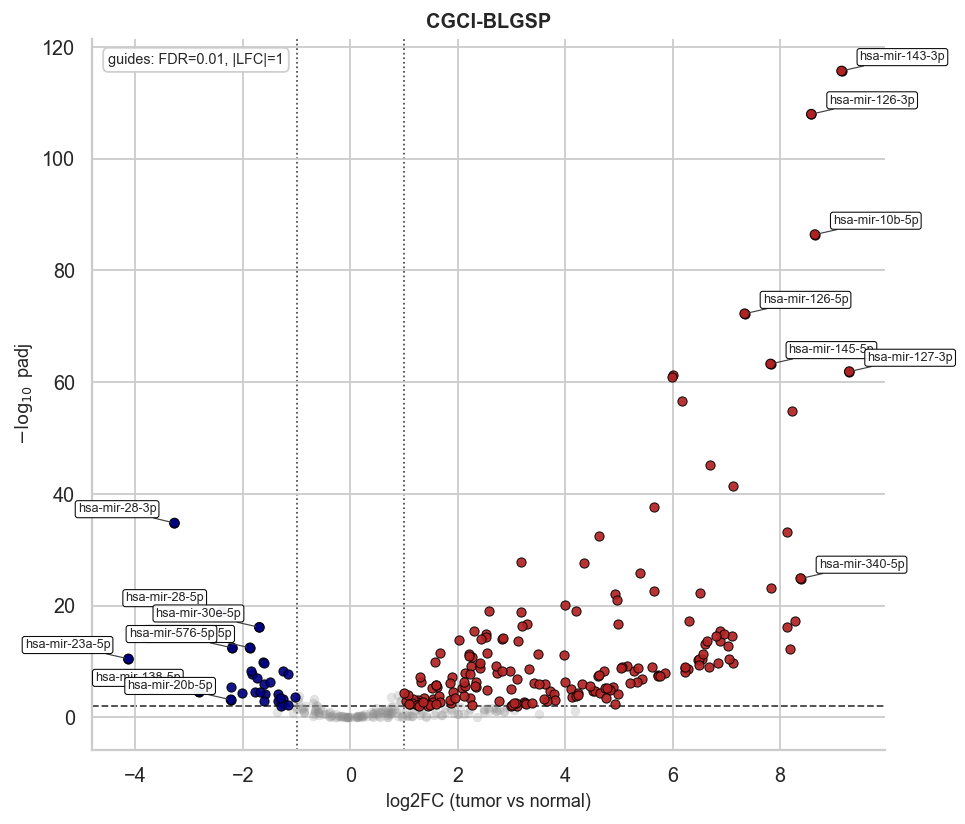

In [15]:
import matplotlib.pyplot as plt

VOLCANO_PROJECT = 'CGCI-BLGSP' #example


_one = de_all[de_all["project_id"] == VOLCANO_PROJECT].copy()
fig, ax = plt.subplots(figsize=(7.6, 6.5), dpi=130)
auxillary_plots.plot_volcano(
    _one,
    ax,
    str(VOLCANO_PROJECT),
    label_top_padj=5,
    label_top_abs_lfc=5,
)
plt.tight_layout()
plt.show()

In [16]:
# Экспорт volcano по всем eligible-проектам в один PDF (отдельная ячейка)
from matplotlib.backends.backend_pdf import PdfPages

VOLCANO_PDF_PATH = FIG_OUT / "volcano_tumor_vs_normal_by_project.pdf"

with PdfPages(VOLCANO_PDF_PATH) as pdf:
    for proj in eligible_projects:
        sub = de_all[de_all["project_id"] == proj]
        if sub.empty:
            continue
        fig, ax = plt.subplots(figsize=(7.6, 6.5), dpi=130)
        auxillary_plots.plot_volcano(
            sub,
            ax,
            str(proj),
            label_top_padj=5,
            label_top_abs_lfc=5,
        )
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print("PDF:", VOLCANO_PDF_PATH.resolve())

PDF: /Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/figures/volcano_tumor_vs_normal_by_project.pdf
